# Feature Engineering

In [149]:
# Load Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

### Load Weekly Clinic Dataset

In [150]:
# Load Weekly Dataset & Audit
df = pd.read_csv(r"c:\Users\earlc\Amdari\Week 2\nexora_care_flow\data\processed\weekly_clinic_appointments.csv")
df['WeekStart'] = pd.to_datetime(df['WeekStart'])
df = df.sort_values(['ClinicID', 'WeekStart']).reset_index(drop=True)

print(f"Loaded {len(df):,} weekly records across {df['ClinicName'].nunique()} clinics.")

# Audit Summary
date_min = df['WeekStart'].min().strftime('%Y-%m-%d')
date_max = df['WeekStart'].max().strftime('%Y-%m-%d')
weeks_per_clinic = len(df) // df['ClinicName'].nunique()

print(
    f"\n Action Complete:\n"
    f"   - Dataset Loaded: {len(df):,} total weekly records across {df['ClinicName'].nunique()} unique clinics (~{weeks_per_clinic} weeks per clinic)\n"
    f"   - Date Span: {date_min} to {date_max}\n"
    f"   - Input Structure: {df.shape[1]} initial columns ({', '.join(df.columns.tolist())})\n"
)
df.head()


Loaded 395 weekly records across 4 clinics.

 Action Complete:
   - Dataset Loaded: 395 total weekly records across 4 unique clinics (~98 weeks per clinic)
   - Date Span: 2024-01-01 to 2025-12-29
   - Input Structure: 6 initial columns (ClinicID, ClinicName, WeekStart, TotalScheduled, Year, Month)



,ClinicID,ClinicName,WeekStart,TotalScheduled,Year,Month
0,1,Nexora Care - Riverside,2024-01-01,269,2024,1
1,1,Nexora Care - Riverside,2024-01-08,316,2024,1
2,1,Nexora Care - Riverside,2024-01-15,261,2024,1
3,1,Nexora Care - Riverside,2024-01-22,284,2024,1
4,1,Nexora Care - Riverside,2024-01-29,283,2024,1


### Build Demand Lag Features
- A clinic's appointment volume last week, 2 weeks ago, and 4 weeks ago are the strongest indicators of next week's demand.

In [151]:
# Create Lag Features per Clinic
df['lag_1w'] = df.groupby('ClinicID')['TotalScheduled'].shift(1)
df['lag_2w'] = df.groupby('ClinicID')['TotalScheduled'].shift(2)
df['lag_4w'] = df.groupby('ClinicID')['TotalScheduled'].shift(4)

# Audit Summary
lag_cols = ['lag_1w', 'lag_2w', 'lag_4w']
null_counts = [df[col].isnull().sum() for col in lag_cols]
corr_lag1 = df['TotalScheduled'].corr(df['lag_1w'])

print(
    f"\n Action Complete:\n"
    f"   - Demand Lag Features Created: {', '.join(lag_cols)} across {df['ClinicName'].nunique()} clinics\n"
    f"   - Initial Boundary NaNs: lag_1w ({null_counts[0]} NaNs), lag_2w ({null_counts[1]} NaNs), lag_4w ({null_counts[2]} NaNs)\n"
    f"   - Autocorrelation Strength: 1-week lag correlation with actual volume = {corr_lag1:.3f}\n"
)
df[['ClinicName', 'WeekStart', 'TotalScheduled', 'lag_1w', 'lag_2w', 'lag_4w']].head(7)



 Action Complete:
   - Demand Lag Features Created: lag_1w, lag_2w, lag_4w across 4 clinics
   - Initial Boundary NaNs: lag_1w (4 NaNs), lag_2w (8 NaNs), lag_4w (16 NaNs)
   - Autocorrelation Strength: 1-week lag correlation with actual volume = 0.808



,ClinicName,WeekStart,TotalScheduled,lag_1w,lag_2w,lag_4w
0,Nexora Care - Riverside,2024-01-01,269,NaN,NaN,NaN
1,Nexora Care - Riverside,2024-01-08,316,269.0,NaN,NaN
2,Nexora Care - Riverside,2024-01-15,261,316.0,269.0,NaN
3,Nexora Care - Riverside,2024-01-22,284,261.0,316.0,NaN
4,Nexora Care - Riverside,2024-01-29,283,284.0,261.0,269.0
5,Nexora Care - Riverside,2024-02-05,321,283.0,284.0,316.0
6,Nexora Care - Riverside,2024-02-12,322,321.0,283.0,261.0


- `lag_1w` gives the model immediate history from the prior week, allowing it to adapt quickly to sudden changes in patient booking volume.


### Build rolling trend feature
- Single-week appointment numbers can jump up or down due to random noise. Taking a 4-week rolling average smooths out noise and exposes the underlying demand trend.

In [152]:
# Create 4-Week Rolling Average per Clinic
df['rolling_mean_4w'] = df.groupby('ClinicID')['TotalScheduled'].shift(1).rolling(window=4).mean()

# Audit Summary
rolling_nulls = df['rolling_mean_4w'].isnull().sum()
rolling_valid = df['rolling_mean_4w'].notnull().sum()
corr_rolling = df['TotalScheduled'].corr(df['rolling_mean_4w'])

print(
    f"\n Action Complete:\n"
    f"   - Rolling Trend Feature Created: 'rolling_mean_4w' (4-week moving average per clinic)\n"
    f"   - Window Warmup Boundary: {rolling_nulls} initial NaNs created ({rolling_nulls // df['ClinicName'].nunique()} weeks per clinic)\n"
    f"   - Valid Feature Rows: {rolling_valid:,} complete records (Correlation with actual demand = {corr_rolling:.3f})\n"
)
df[['ClinicName', 'WeekStart', 'TotalScheduled', 'lag_1w', 'rolling_mean_4w']].head(8)



 Action Complete:
   - Rolling Trend Feature Created: 'rolling_mean_4w' (4-week moving average per clinic)
   - Window Warmup Boundary: 16 initial NaNs created (4 weeks per clinic)
   - Valid Feature Rows: 379 complete records (Correlation with actual demand = 0.833)



,ClinicName,WeekStart,TotalScheduled,lag_1w,rolling_mean_4w
0,Nexora Care - Riverside,2024-01-01,269,NaN,NaN
1,Nexora Care - Riverside,2024-01-08,316,269.0,NaN
2,Nexora Care - Riverside,2024-01-15,261,316.0,NaN
3,Nexora Care - Riverside,2024-01-22,284,261.0,NaN
4,Nexora Care - Riverside,2024-01-29,283,284.0,282.50
5,Nexora Care - Riverside,2024-02-05,321,283.0,286.00
6,Nexora Care - Riverside,2024-02-12,322,321.0,287.25
7,Nexora Care - Riverside,2024-02-19,334,322.0,302.50


- `rolling_mean_4w` provides a stable baseline demand level, protecting models from overreacting to single-week spikes.


#### Encode Month Cyclically

In [153]:
# Cyclical Month Features
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Audit Summary
sin_min, sin_max = df['Month_Sin'].min(), df['Month_Sin'].max()
cos_min, cos_max = df['Month_Cos'].min(), df['Month_Cos'].max()
null_count = df[['Month_Sin', 'Month_Cos']].isnull().sum().sum()

print(
    f"\n Action Complete:\n"
    f"   - Cyclical Features Generated: 'Month_Sin' and 'Month_Cos' (12-month trigonometric cycle)\n"
    f"   - Trigonometric Bounding Range: Sine [{sin_min:.3f}, {sin_max:.3f}] | Cosine [{cos_min:.3f}, {cos_max:.3f}]\n"
    f"   - Completeness Audit: {null_count} missing values across all {len(df):,} records\n"
)
df[['WeekStart', 'Month', 'Month_Sin', 'Month_Cos']].head()



 Action Complete:
   - Cyclical Features Generated: 'Month_Sin' and 'Month_Cos' (12-month trigonometric cycle)
   - Trigonometric Bounding Range: Sine [-1.000, 1.000] | Cosine [-1.000, 1.000]
   - Completeness Audit: 0 missing values across all 395 records



,WeekStart,Month,Month_Sin,Month_Cos
0,2024-01-01,1,0.5,0.866025
1,2024-01-08,1,0.5,0.866025
2,2024-01-15,1,0.5,0.866025
3,2024-01-22,1,0.5,0.866025
4,2024-01-29,1,0.5,0.866025


#### Create Flu Season & Holiday Indicators

In [154]:
# Flu Season and Holiday Flags
df['Is_Flu_Season'] = df['Month'].isin([10, 11, 12, 1, 2]).astype(int)
df['Is_Holiday_Week'] = df['WeekStart'].dt.isocalendar().week.isin([47, 52]).astype(int)

# Audit Summary
flu_weeks = df['Is_Flu_Season'].sum()
flu_pct = df['Is_Flu_Season'].mean() * 100
holiday_weeks = df['Is_Holiday_Week'].sum()
holiday_pct = df['Is_Holiday_Week'].mean() * 100

flu_avg = df.groupby('Is_Flu_Season')['TotalScheduled'].mean()[1]
non_flu_avg = df.groupby('Is_Flu_Season')['TotalScheduled'].mean()[0]
flu_surge = ((flu_avg - non_flu_avg) / non_flu_avg) * 100

print(
    f"\n Action Complete:\n"
    f"   - Flu Season Flag: Active for {flu_weeks:,} weekly records ({flu_pct:.1f}% of total) | Demand Surge = +{flu_surge:.1f}%\n"
    f"   - Holiday Flag: Active for {holiday_weeks:,} holiday weeks ({holiday_pct:.1f}% of total)\n"
    f"   - Average Weekly Appointments: Flu Season = {flu_avg:.1f} appts/week vs Regular Season = {non_flu_avg:.1f} appts/week\n"
)
df[['WeekStart', 'Month', 'Is_Flu_Season', 'Is_Holiday_Week']].tail(10)



 Action Complete:
   - Flu Season Flag: Active for 163 weekly records (41.3% of total) | Demand Surge = +5.8%
   - Holiday Flag: Active for 16 holiday weeks (4.1% of total)
   - Average Weekly Appointments: Flu Season = 338.3 appts/week vs Regular Season = 319.9 appts/week



,WeekStart,Month,Is_Flu_Season,Is_Holiday_Week
385,2025-10-27,10,1,0
386,2025-11-03,11,1,0
387,2025-11-10,11,1,0
388,2025-11-17,11,1,1
389,2025-11-24,11,1,0
390,2025-12-01,12,1,0
391,2025-12-08,12,1,0
392,2025-12-15,12,1,0
393,2025-12-22,12,1,1
394,2025-12-29,12,1,0


In [155]:
# Drop Initial NaN Rows & Save
df_clean = df.dropna().reset_index(drop=True)

# Save Weekly Features
output_path = r"c:\Users\earlc\Amdari\Week 2\nexora_care_flow\data\processed\weekly_features.csv"
df_clean.to_csv(output_path, index=False)

print(f"Original Records: {len(df):,} rows")
print(f"Dropped Initial Lag Rows: {len(df) - len(df_clean):,} rows (4 weeks x 4 clinics)")
print(f"Final Clean Feature Dataset: {len(df_clean):,} rows saved to 'data/processed/weekly_features.csv'")

# Audit Summary
file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
dropped_rows = len(df) - len(df_clean)
weeks_per_clinic_clean = len(df_clean) // df_clean['ClinicName'].nunique()

print(
    f"\n Action Complete:\n"
    f"   - Warmup Trimming: Dropped {dropped_rows:,} initial lag rows ({dropped_rows // df_clean['ClinicName'].nunique()} weeks x {df_clean['ClinicName'].nunique()} clinics)\n"
    f"   - Clean Feature Dataset: Retained {len(df_clean):,} rows (~{weeks_per_clinic_clean} weeks per clinic) across {df_clean.shape[1]} engineered features\n"
    f"   - Export Audit: File saved to '{output_path}' (Size: {file_size_mb:.2f} MB | Nulls: {df_clean.isnull().sum().sum()})\n"
)
df_clean.head()


Original Records: 395 rows
Dropped Initial Lag Rows: 16 rows (4 weeks x 4 clinics)
Final Clean Feature Dataset: 379 rows saved to 'data/processed/weekly_features.csv'

 Action Complete:
   - Warmup Trimming: Dropped 16 initial lag rows (4 weeks x 4 clinics)
   - Clean Feature Dataset: Retained 379 rows (~94 weeks per clinic) across 14 engineered features
   - Export Audit: File saved to 'c:\Users\earlc\Amdari\Week 2\nexora_care_flow\data\processed\weekly_features.csv' (Size: 0.04 MB | Nulls: 0)



,ClinicID,ClinicName,WeekStart,TotalScheduled,Year,Month,lag_1w,lag_2w,lag_4w,rolling_mean_4w,Month_Sin,Month_Cos,Is_Flu_Season,Is_Holiday_Week
0,1,Nexora Care - Riverside,2024-01-29,283,2024,1,284.0,261.0,269.0,282.50,0.500000,0.866025,1,0
1,1,Nexora Care - Riverside,2024-02-05,321,2024,2,283.0,284.0,316.0,286.00,0.866025,0.500000,1,0
2,1,Nexora Care - Riverside,2024-02-12,322,2024,2,321.0,283.0,261.0,287.25,0.866025,0.500000,1,0
3,1,Nexora Care - Riverside,2024-02-19,334,2024,2,322.0,321.0,284.0,302.50,0.866025,0.500000,1,0
4,1,Nexora Care - Riverside,2024-02-26,332,2024,2,334.0,322.0,283.0,315.00,0.866025,0.500000,1,0


#### Comparing Actual Volume vs Engineered Features


 Action Complete:
   - Sample Clinic Verification: 'Nexora Care - Lakeside' across 101 clean weekly observations
   - Average Weekly Metrics: Actual Volume = 435.3 appts/week | Lag 1W = 438.2 appts/week | Rolling 4W = 437.1 appts/week
   - Feature Alignment Signal: Lag 1W correlation = 0.360 | Rolling Mean 4W correlation = 0.252



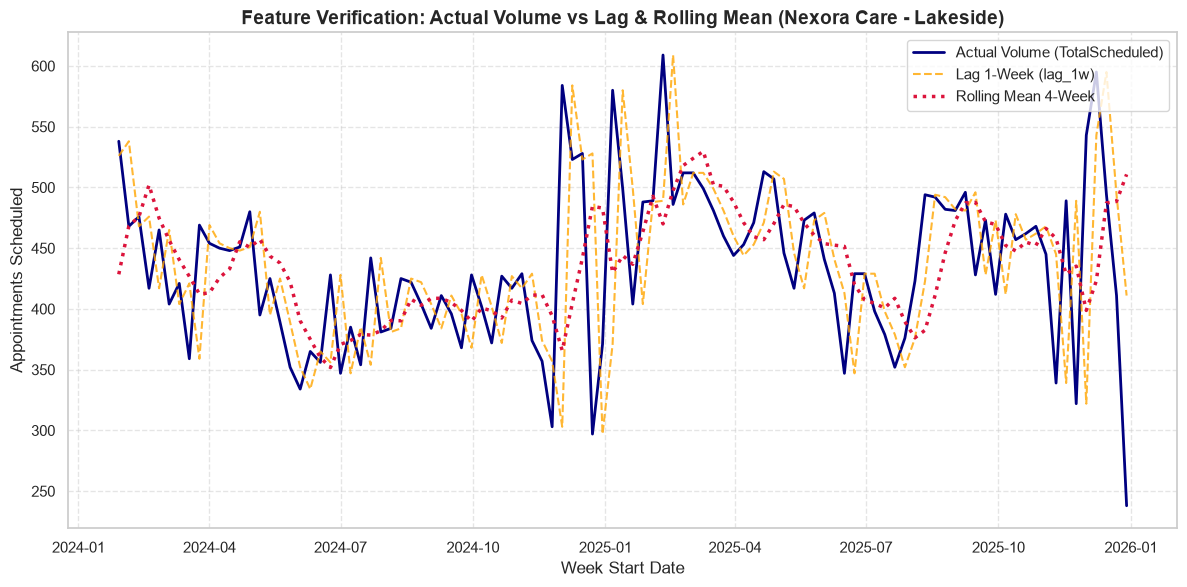

In [156]:
# Plot Actual Volume vs Features for Lakeside Clinic
lakeside_df = df_clean[df_clean['ClinicName'] == 'Nexora Care - Lakeside'].copy()

# Audit Summary
sample_clinic = lakeside_df['ClinicName'].iloc[0]
sample_weeks = len(lakeside_df)
mean_actual = lakeside_df['TotalScheduled'].mean()
mean_lag1 = lakeside_df['lag_1w'].mean()
mean_roll4 = lakeside_df['rolling_mean_4w'].mean()

corr_lag1_lake = lakeside_df['TotalScheduled'].corr(lakeside_df['lag_1w'])
corr_roll4_lake = lakeside_df['TotalScheduled'].corr(lakeside_df['rolling_mean_4w'])

print(
    f"\n Action Complete:\n"
    f"   - Sample Clinic Verification: '{sample_clinic}' across {sample_weeks} clean weekly observations\n"
    f"   - Average Weekly Metrics: Actual Volume = {mean_actual:.1f} appts/week | Lag 1W = {mean_lag1:.1f} appts/week | Rolling 4W = {mean_roll4:.1f} appts/week\n"
    f"   - Feature Alignment Signal: Lag 1W correlation = {corr_lag1_lake:.3f} | Rolling Mean 4W correlation = {corr_roll4_lake:.3f}\n"
)

# Plot Line Plot for Feature Verification
plt.figure(figsize=(12, 6))
sns.lineplot(data=lakeside_df, x='WeekStart', y='TotalScheduled', label='Actual Volume (TotalScheduled)', color='navy', linewidth=2)
sns.lineplot(data=lakeside_df, x='WeekStart', y='lag_1w', label='Lag 1-Week (lag_1w)', color='orange', linestyle='--', alpha=0.8)
sns.lineplot(data=lakeside_df, x='WeekStart', y='rolling_mean_4w', label='Rolling Mean 4-Week', color='crimson', linestyle=':', linewidth=2.5)

plt.title(f'Feature Verification: Actual Volume vs Lag & Rolling Mean ({sample_clinic})', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Appointments Scheduled')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


- **`lag_1w`** tracks actual volume closely with a 1-week shift.
- **`rolling_mean_4w`** provides a smooth center line through weekly noise.
- Together, these features give forecasting algorithms both **short-term momentum** and **medium-term stability**.
